<a href="https://colab.research.google.com/github/sai12lohitha/STUDENT-STUDY-GUIDE/blob/main/Predicting_Stock_Prices_with_Python_and_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Import the libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')


In [3]:
def load_stock_data(csv_file):
  df=pd.read_csv(csv_file)
  df['Date']=pd.to_datetime(df['Date'])
  df.set_index('Date',inplace=True)
  return df

In [26]:
def prepare_data(df,forecast_days=30):
  df=df[['Close']].copy()
  df['Prediction']=df[['Close']].shift(-forecast_days)
  x=np.array(df.drop(['Prediction'],axis=1))[:-forecast_days]
  y=np.array(df['Prediction'])[:-forecast_days]
  return x,y,df

In [47]:
def train_and_predict(x,y,df,forecast_days=30):
  x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
  model=LinearRegression()
  model.fit(x_train,y_train)
  predictions=model.predict(x_test)
  mse=mean_squared_error(y_test,predictions)
  r2=r2_score(y_test,predictions)
  print("Model Evalution:")
  print(f"MSE: {mse:2f}")
  print(f"R2 : {r2:4f}")
  x_future = np.array(df.drop(['Prediction'], axis=1))[-forecast_days:]
  future_predictions=model.predict(x_future)
  return future_predictions,model

In [36]:
def plot_predictions(df,future_days,future_predictions):
  df_future=df.copy()
  last_date=df.index[-1]
  future_dates=pd.date_range(last_date+pd.Timedelta(days=1),periods=future_days)
  plt.figure(figsize=(12,6))
  plt.plot(df['Close'],label='Historical close price')
  plt.plot(future_dates,future_predictions,label='predicted future price',linestyle='--')
  plt.xlabel('Date')
  plt.ylabel('Price')
  plt.title('stock price prediction')
  plt.legend()
  plt.show()


In [48]:
import os
import glob

# Find the 'stocks' directory in the downloaded dataset path
stocks_dir = os.path.join(path, 'stocks')

# Find all CSV files inside the 'stocks' folder
csv_files = glob.glob(os.path.join(stocks_dir, '*.csv'))

if csv_files:
    # Select one stock file to analyze (e.g., ESI.csv)
    selected_stock_file = csv_files[0]
    print(f"Selected stock file: {selected_stock_file}")

    forcast_days = 30
    stock_data = load_stock_data(selected_stock_file)
    print(stock_data.head())
else:
    print(f"No CSV files found in {stocks_dir}. Please check your dataset files.")

Selected stock file: /root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/stocks/ESI.csv
             Open   High    Low  Close  Adj Close  Volume
Date                                                     
2013-10-22  12.00  12.00  12.00  12.00      12.00  300000
2013-10-23  12.00  12.00  12.00  12.00      12.00       0
2013-10-24  12.00  12.00  12.00  12.00      12.00       0
2013-10-25  11.75  11.75  11.75  11.75      11.75  514200
2013-10-28  11.75  11.75  11.75  11.75      11.75       0


Model Evalution:
MSE: 4.721064
R2 : 0.870766


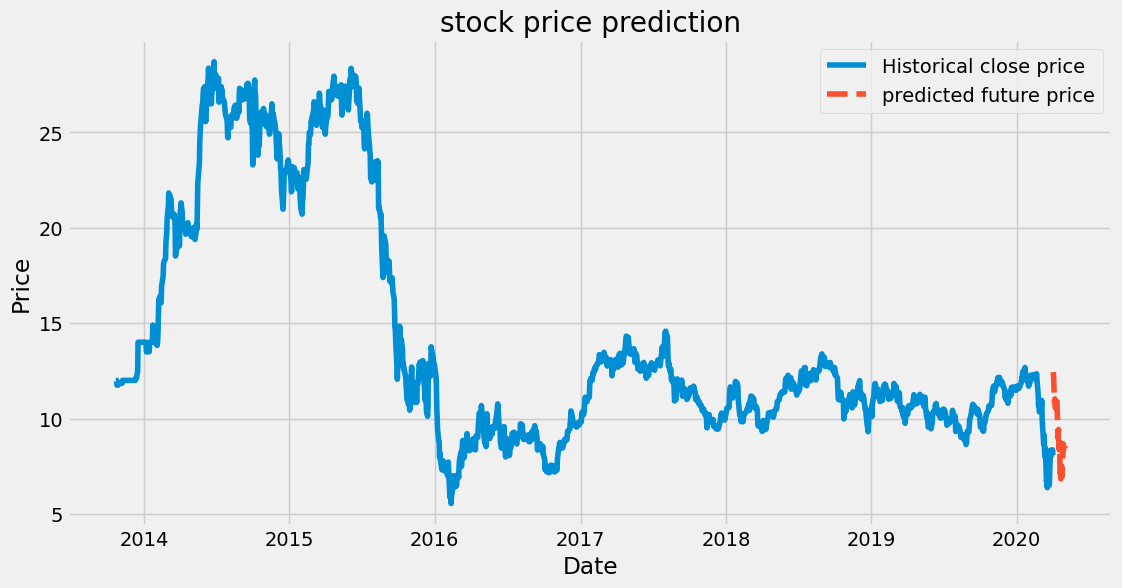

Future Price Predictions:
[12.43473507 12.15356849 11.43190761 10.8602029  11.02890303 10.56029235
 10.59778117 10.90706415 10.82271408 11.12262463 10.24163694  9.87612029
  8.95764378  9.42625447  8.72333844  8.35782179  8.77957123  7.13006186
  7.39248359  6.83952329  7.82360545  7.67365018  6.96136218  7.59867254
  8.20786652  8.6764772   8.37656665  8.59212713  8.69522116  8.44217186]


In [46]:
X,y,df=prepare_data(stock_data,forcast_days)
future_predictions,model=train_and_predict(X,y,df,forcast_days)
plot_predictions(df,forcast_days,future_predictions)
print("Future Price Predictions:")
print(future_predictions)